In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
#Display Setting
pd.set_option('display.max_columns',None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
# Load all datasets

crude_oil   = pd.read_csv('crude_oil_data.csv')
fuel_prices = pd.read_csv('fuel_price_data.csv')
currency    = pd.read_csv('currency_data.csv')
shipping    = pd.read_csv('shipping_data.csv')
stocks      = pd.read_csv('stock_market_data.csv')
sentiment   = pd.read_csv('news_sentiment_data.csv')

print("All dataset loaded")

FileNotFoundError: [Errno 2] No such file or directory: 'crude_oil_data.csv'

In [ ]:
# Fix dates in every dataset


datasets = {
    'crude_oil'   : crude_oil,
    'fuel_prices' : fuel_prices,
    'currency'    : currency,
    'shipping'    : shipping,
    'stocks'      : stocks,
    'sentiment'   : sentiment
}

for name, df in datasets.items():
    # If date column is numeric (Excel serial), convert it
    if df['Date'].dtype in ['int64', 'float64']:
        df['Date'] = (
            pd.to_datetime('1899-12-30') +
            pd.to_timedelta(df['Date'], unit='D')
        )
    else:
        df['Date'] = pd.to_datetime(
            df['Date'],
            format='mixed',
            dayfirst=True
        )

    print(
        f"{name}: {df['Date'].min().date()} to "
        f"{df['Date'].max().date()} | {len(df)} rows"
    )

crude_oil: 2026-03-25 to 2026-04-08 | 15 rows
fuel_prices: 2026-04-01 to 2026-04-08 | 96 rows
currency: 2026-04-01 to 2026-04-08 | 48 rows
shipping: 2026-04-01 to 2026-04-08 | 32 rows
stocks: 2026-04-01 to 2026-04-08 | 48 rows
sentiment: 2026-04-01 to 2026-04-08 | 56 rows


In [ ]:
# Quick data quality check

for name, df in datasets.items():
    nulls = df.isnull().sum().sum()
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} cols, {nulls} nulls")

crude_oil: 15 rows, 6 cols, 0 nulls
fuel_prices: 96 rows, 6 cols, 0 nulls
currency: 48 rows, 5 cols, 0 nulls
shipping: 32 rows, 7 cols, 0 nulls
stocks: 48 rows, 7 cols, 0 nulls
sentiment: 56 rows, 7 cols, 0 nulls


In [ ]:
df.head()

,Date,News_Source,Article_Mentions,Sentiment_Score,Sentiment_Label,Headline_Avg_Length,Shares_and_Engagement
0,2026-04-01,Reuters,48,0.30,Neutral,51,47281
1,2026-04-01,Bloomberg,46,0.30,Neutral,66,14191
2,2026-04-01,AP News,39,0.30,Neutral,47,28284
3,2026-04-01,BBC,57,0.30,Neutral,70,23101
4,2026-04-01,CNBC,35,0.30,Neutral,70,28756


In [ ]:
#Crisis Phase % change Summary

crude_oil['Date'] = pd.to_datetime(crude_oil['Date'])

crude_crisis = crude_oil[
    (crude_oil['Date'] >= '2026-04-01') &
    (crude_oil['Date'] <= '2026-04-08')
].copy()

def assign_phase(date):
    if date <= pd.Timestamp('2026-04-03'):
        return 'Pre_crisis'
    elif date <= pd.Timestamp('2026-04-06'):
        return 'Escalation'
    else:
        return 'Peak'

crude_crisis['crisis_phase'] = crude_crisis['Date'].apply(assign_phase)

print(crude_crisis[['Date', 'crisis_phase']])

         Date crisis_phase
7  2026-04-01   Pre_crisis
8  2026-04-02   Pre_crisis
9  2026-04-03   Pre_crisis
10 2026-04-04   Escalation
11 2026-04-05   Escalation
12 2026-04-06   Escalation
13 2026-04-07         Peak
14 2026-04-08         Peak


In [ ]:
# calculate % change from day 0 for all key metrics

# Get day 0 values (April 1)

day0_wti = crude_crisis[crude_crisis['Date'] == '2026-04-01']['WTI_Crude_USD_per_barrel'].values[0]
day0_sentiment = sentiment[sentiment['Date'] == '2026-04-01']['Sentiment_Score'].mean()
day0_shipping = shipping[shipping['Date'] == '2026-04-01']['Avg_Freight_Rate_USD_per_TEU'].mean()

In [ ]:
#calculate daily % change from day 0 

crude_crisis["wti_pct_from_day0"] = (crude_crisis["WTI_Crude_USD_per_barrel"]-day0_wti) / day0_wti * 100
print(crude_crisis[['Date','WTI_Crude_USD_per_barrel','wti_pct_from_day0']])

         Date  WTI_Crude_USD_per_barrel  wti_pct_from_day0
7  2026-04-01                     93.49               0.00
8  2026-04-02                     94.24               0.80
9  2026-04-03                     93.88               0.42
10 2026-04-04                    109.76              17.40
11 2026-04-05                    112.52              20.36
12 2026-04-06                    110.24              17.92
13 2026-04-07                    109.42              17.04
14 2026-04-08                    112.40              20.23


In [ ]:
# Correlation metrix

# oil-daily WTI
crude_crisis = crude_oil[
    (crude_oil['Date'] >= '2026-04-01') &
    (crude_oil['Date'] <= '2026-04-08')
].copy()
daily_oil = crude_crisis.groupby("Date")["WTI_Crude_USD_per_barrel"].mean().reset_index()
daily_oil.columns = ['Date', 'WTI_Oil']

# Sentiment : daily average score + total articles
daily_sentiment = sentiment.groupby('Date').agg(
    Sentiment_Score  = ('Sentiment_Score',  'mean'),
    Total_Articles   = ('Article_Mentions', 'sum')
).reset_index()

# Stock - energy vs broad market
daily_stocks = (stocks.pivot_table
                (index="Date",columns="Sector",values="Percent_Change",aggfunc="mean").reset_index())

# Shipping — average freight rate
daily_shipping = shipping.groupby("Date").agg(
    Avg_Freight_Rate = ('Avg_Freight_Rate_USD_per_TEU', 'mean'),
    Avg_Delay        = ('Days_Delay_Average', 'mean')
).reset_index()

# Currency - USD Index
daily_usd = currency[currency["Currency_Pair"] == 'USD_Index'][["Date","Exchange_Rate"]].copy()
daily_usd.columns = ["Date","USD_Index"]

# Combine all metrics
master = daily_oil.merge(daily_sentiment,on="Date",how="left")
master = master.merge(daily_stocks,on="Date",how="left")
master = master.merge(daily_shipping,on="Date",how="left")
master = master.merge(daily_usd,on="Date",how="left")
print(master.head())





        Date  WTI_Oil  Sentiment_Score  Total_Articles  Broad Market  Energy  \
0 2026-04-01    93.49             0.30             334         -0.40   -0.75   
1 2026-04-02    94.24             0.22             666         -0.72    0.33   
2 2026-04-03    93.88             0.14             914         -1.05    1.41   
3 2026-04-04   109.76             0.06            1256         -1.38    2.49   
4 2026-04-05   112.52            -0.02            1542         -1.70    3.58   

   Avg_Freight_Rate  Avg_Delay  USD_Index  
0           1607.98       0.00     104.50  
1           2077.15       0.50     104.85  
2           2004.09       1.00     105.20  
3           1968.62       1.50     105.55  
4           2485.75       2.00     105.90  


In [ ]:
correlation_matric = master.corr(numeric_only=True)
print(correlation_matric)


                  WTI_Oil  Sentiment_Score  Total_Articles  Broad Market  \
WTI_Oil              1.00            -0.86            0.89         -0.85   
Sentiment_Score     -0.86             1.00           -0.99          1.00   
Total_Articles       0.89            -0.99            1.00         -0.99   
Broad Market        -0.85             1.00           -0.99          1.00   
Energy               0.86            -1.00            0.99         -1.00   
Avg_Freight_Rate     0.75            -0.88            0.90         -0.88   
Avg_Delay            0.86            -1.00            0.99         -1.00   
USD_Index            0.86            -1.00            0.99         -1.00   

                  Energy  Avg_Freight_Rate  Avg_Delay  USD_Index  
WTI_Oil             0.86              0.75       0.86       0.86  
Sentiment_Score    -1.00             -0.88      -1.00      -1.00  
Total_Articles      0.99              0.90       0.99       0.99  
Broad Market       -1.00             -0.88     

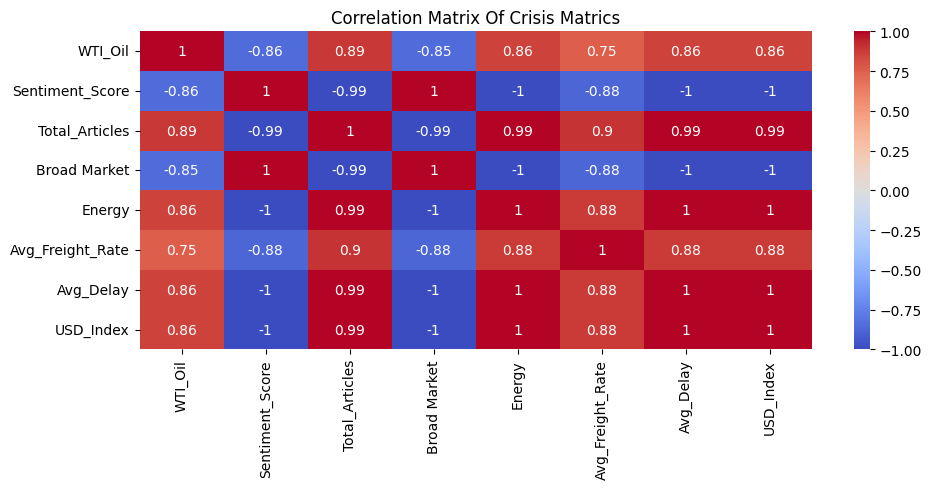

Chart saved successfully.


In [ ]:
# Correlation Matric Heatmap

plt.figure(figsize=(10,5))
sns.heatmap(correlation_matric,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix Of Crisis Matrics")
plt.tight_layout()
plt.savefig("Correlation_heatmap.png")
plt.show()

print("Chart saved successfully.")

In [ ]:
# Calculate Fuel Price % Change

USD_Fuel = fuel_prices[fuel_prices['Currency'] == 'USD'].copy()

country_change = USD_Fuel.groupby('Country').agg(
    Min_Price=('Fuel_Price_Per_Liter_USD', 'min'),
    Max_Price=('Fuel_Price_Per_Liter_USD', 'max')
).reset_index()


# Percentage Change Formula
country_change['Fuel_Price_%_Change'] = (
    (country_change['Max_Price'] - country_change['Min_Price'])
    / country_change['Min_Price']
) * 100

country_change = country_change.sort_values(by='Fuel_Price_%_Change',ascending=False)

print(country_change.head())

     Country  Min_Price  Max_Price  Fuel_Price_%_Change
2     Canada       3.12       3.50                12.18
8         UK       5.42       6.08                12.18
0  Australia       4.95       5.54                11.92
3      China       5.12       5.70                11.33
5      Japan       5.34       5.93                11.05


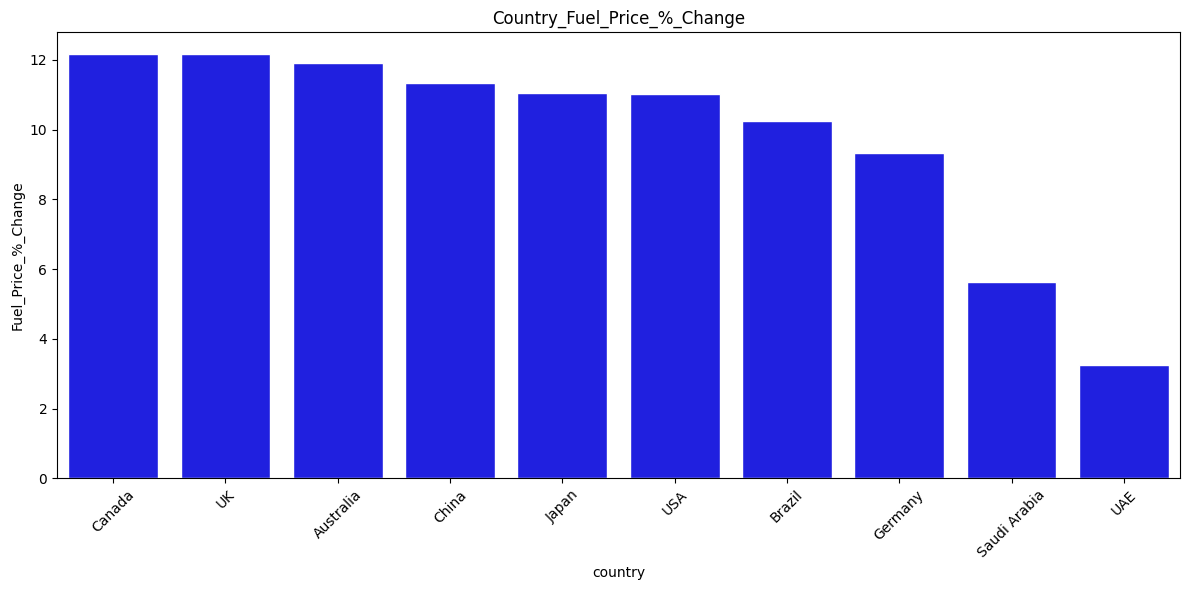

chart saved successfully


In [ ]:
# Plot Bar chart

plt.figure(figsize=(12,6))
sns.barplot(data=country_change,x="Country",y="Fuel_Price_%_Change",edgecolor="white",color="blue")
plt.xlabel("country")
plt.ylabel("Fuel_Price_%_Change")
plt.title("Country_Fuel_Price_%_Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Country_Fuel_Price_%_Change.png")
plt.show()

print("chart saved successfully")

- Key Finding:

- UAE and Saudi Arabia show the lowest fuel price increase (3.2% and 5.6%) because they are oil-producing     nations with government-subsidized fuel prices.
- Canada, UK, and Australia - which import oil at market rates - absorbed the full shock of the crisis, showing 12% increase in just 8 days.

In [ ]:
# Export all clean data for Power BI

# Master Table 
master.to_csv("powerbi_master.csv",index=False)

# Country Fuel Price % change
country_change.to_csv("powerbi_country_change_%_change.csv",index=False)

# Full Stock Data(For individual stock analysis)
stocks["Date"] = pd.to_datetime(stocks["Date"])
stocks_clean = stocks[stocks["Date"] >= "2026-04-01"].copy()
stocks_clean.to_csv("powerbi_stocks_clean.csv",index=False)

# Shipping Data
shipping["Date"] = pd.to_datetime(shipping["Date"])
shipping_clean = shipping[shipping["Date"] >= "2026-04-01"].copy()
shipping_clean.to_csv("powerbi_shipping_clean.csv",index=False)

# Crude_Oil(Full period including pre-crisis baseline)
crude_oil.to_csv("powerbi_crude_oil.csv",index=False)

# Sentiment full detail
sentiment['Date'] = pd.to_datetime(sentiment['Date'],format='%d/%m/%Y')
sentiment_clean = sentiment[sentiment["Date"] >= "2026-04-01"].copy()
print(sentiment_clean['Date'].unique())
sentiment_clean.to_csv("powerbi_sentiment_clean.csv",index=False)

print("all files saved succssfully")
print("files to import in powerbi")
print("powerbi_master.csv")
print("powerbi_country_change_%_change.csv")
print("powerbi_stocks_clean.csv")
print("powerbi_shipping_clean.csv")
print("powerbi_crude_oil.csv")
print("powerbi_sentiment_clean.csv")

all files saved succssfully
files to import in powerbi
powerbi_master.csv
powerbi_country_change_%_change.csv
powerbi_stocks_clean.csv
powerbi_shipping_clean.csv
powerbi_crude_oil.csv
powerbi_sentiment_clean.csv


In [4]:
sentiment['Date'] = pd.to_datetime(sentiment['Date'],format='%d/%m/%Y')
sentiment_clean = sentiment[sentiment["Date"] >= "2026-04-01"].copy()
print(sentiment_clean['Date'].unique())

NameError: name 'sentiment' is not defined